In [1]:
import pandas as pd
import glob
import os
from extract import delsys_csv_breakdown
from preprocessing import butter_bandpass_filter, resamp, peak_normalization, sync

initial_data_path = '/Users/clmckeev/Library/CloudStorage/OneDrive-SharedLibraries-IndianaUniversity/[Sec-E] BL-Phys-NDD_EMG - Documents/NDD_EMG/Data/Raw/All'


In [2]:
subject_id = '004'
subject_folder = os.path.join(initial_data_path,subject_id)
(DT, sensor_config, delsys_data) = delsys_csv_breakdown(os.path.join(subject_folder,f"{subject_id}_emg.csv"))
delsys_data.dropna()

/Users/clmckeev/Library/CloudStorage/OneDrive-SharedLibraries-IndianaUniversity/[Sec-E] BL-Phys-NDD_EMG - Documents/NDD_EMG/Code/extract.py:39: DtypeWarning: Columns (0:  EMG 1 (mV), 1:  EMG 2 Time Series (s), 2:  EMG 2 (mV), 3:  ACC X Time Series (s), 4:  ACC X (G), 5:  ACC Y Time Series (s), 6:  ACC Y (G), 7:  ACC Z Time Series (s), 8:  ACC Z (G), 9:  GYRO X Time Series (s), 10:  GYRO X (deg/s), 11:  GYRO Y Time Series (s), 12:  GYRO Y (deg/s), 13:  GYRO Z Time Series (s), 14:  GYRO Z (deg/s), 15:  EMG 1 Time Series (s), 16:  EMG 1 (mV).1, 17:  EMG 2 Time Series (s).1, 18:  EMG 2 (mV).1, 19:  ACC X Time Series (s).1, 20:  ACC X (G).1, 21:  ACC Y Time Series (s).1, 22:  ACC Y (G).1, 23:  ACC Z Time Series (s).1, 24:  ACC Z (G).1, 25:  GYRO X Time Series (s).1, 26:  GYRO X (deg/s).1, 27:  GYRO Y Time Series (s).1, 28:  GYRO Y (deg/s).1, 29:  GYRO Z Time Series (s).1, 30:  GYRO Z (deg/s).1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(de

,EMG 1 Time Series (s),EMG 1 (mV),EMG 2 Time Series (s),EMG 2 (mV),ACC X Time Series (s),ACC X (G),ACC Y Time Series (s),ACC Y (G),ACC Z Time Series (s),ACC Z (G),...,ACC Z Time Series (s) 2,ACC Z (G) 2,GYRO X Time Series (s) 2,GYRO X (deg/s) 2,GYRO Y Time Series (s) 2,GYRO Y (deg/s) 2,GYRO Z Time Series (s) 2,GYRO Z (deg/s) 2,Analog_In_1 Time Series (s),Analog_In_1 (V)
0,0.000000,0.006378,0.000000,0.086946,0.000000,-0.310547,0.000000,0.306641,0.000000,0.883789,...,0.000000,0.477051,0.00000,317.134155,0.00000,137.347565,0.00000,-81.036591,0.000000,-0.002915
1,0.000562,0.009735,0.000562,0.078218,0.001038,-0.303711,0.001038,0.309082,0.001038,0.878906,...,0.001038,0.470703,0.00135,316.463409,0.00135,139.878052,0.00135,-78.902443,0.000021,-0.002679
2,0.001125,0.009064,0.001125,0.039948,0.002077,-0.304199,0.002077,0.307129,0.002077,0.889648,...,0.002077,0.462402,0.00270,316.280487,0.00270,142.286591,0.00270,-76.554878,0.000042,-0.002875
3,0.001687,0.007050,0.001687,-0.001679,0.003115,-0.307129,0.003115,0.305176,0.003115,0.885254,...,0.003115,0.479980,0.00405,315.426849,0.00405,146.158539,0.00405,-71.463417,0.000063,-0.003003
4,0.002250,0.006378,0.002250,-0.031220,0.004154,-0.313477,0.004154,0.301758,0.004154,0.890625,...,0.004154,0.465820,0.00540,315.091461,0.00540,148.048782,0.00540,-69.268295,0.000083,-0.002673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264985,149.054062,-0.036591,149.054062,0.005036,275.176731,0.013184,275.176731,0.124512,275.176731,0.951660,...,275.176731,0.796875,357.72975,-6.707317,357.72975,14.573171,357.72975,0.182927,5.520521,-0.002503
264986,149.054625,-0.037262,149.054625,0.005036,275.177769,0.025879,275.177769,0.120606,275.177769,0.960449,...,275.177769,0.791016,357.73110,-6.798780,357.73110,14.969513,357.73110,0.000000,5.520542,-0.002594
264987,149.055187,-0.040955,149.055187,0.007050,275.178808,0.027344,275.178808,0.136719,275.178808,0.944336,...,275.178808,0.792969,357.73245,-6.890244,357.73245,14.786586,357.73245,0.182927,5.520562,-0.002739
264988,149.055750,-0.045991,149.055750,0.005036,275.179846,0.028320,275.179846,0.134277,275.179846,0.939453,...,275.179846,0.794434,357.73380,-6.646342,357.73380,15.091464,357.73380,0.091463,5.520583,-0.002852


In [3]:
p_data = pd.read_csv(glob.glob(os.path.join(glob.escape(subject_folder),'*info.csv'))[0])
mat_data = pd.read_csv(glob.glob(os.path.join(glob.escape(subject_folder),'mat*.csv'))[0])
target_data = pd.read_csv(glob.glob(os.path.join(glob.escape(subject_folder),'target*.csv'))[0])


In [6]:
print(mat_data)

      1216446  9  9.1  13  1  8  18  7  7.1  21  ...  7.6  15.3  4.4  1.9  \
0     1216981  9    9  13  1  8  18  8    6  21  ...    6    15    5    1   
1     1217015  9    9  13  1  8  18  8    6  21  ...    7    15    4    1   
2     1217049  9    9  13  1  8  18  8    6  21  ...    7    14    6    1   
3     1217084  9    9  13  1  8  18  7    7  21  ...    7    13    6    1   
4     1217118  9    9  13  1  8  18  7    6  21  ...    7    13    5    1   
...       ... ..  ...  .. .. ..  .. ..  ...  ..  ...  ...   ...  ...  ...   
7332  1543571  9   11  13  1  8  18  9   10  21  ...    4    11    9    1   
7333  1543605  9   11  13  1  8  18  7    9  21  ...    4    11    9    1   
7334  1543639  9    9  13  1  8  18  7    9  21  ...    4     9    9    1   
7335  1543673  9    9  13  1  9  18  7    9  21  ...    4    11    9    1   
7336  1543707  9    9  13  1  9  18  7   10  21  ...    4    11    9    1   

      13.5  8.5  20.4  8.6  8.7  9.8  
0       12    8    17    8    8    9

In [7]:
EMG_1 = delsys_data[['EMG 1 Time Series (s)', 'EMG 1 (mV)', 'EMG 2 (mV)']].dropna()
EMG_1.columns = ['Time', 'EMG1', 'EMG2']
Analog = delsys_data[[ 'Analog_In_1 Time Series (s)','Analog_In_1 (V)']]
Analog.columns = ['Time', 'Analog']

t_delay = sync(Analog, target_data, a_event_cutoff=0.01)
target_data['hitTime'] = pd.to_datetime(target_data['hitTime'], unit='s') + pd.to_timedelta(t_delay, unit='s')
mat_data.iloc[:, 0] = pd.to_datetime(mat_data.iloc[:, 0], unit='s') + pd.to_timedelta(t_delay, unit='s')

TypeError: cannot perform __truediv__ with this index type: DatetimeArray

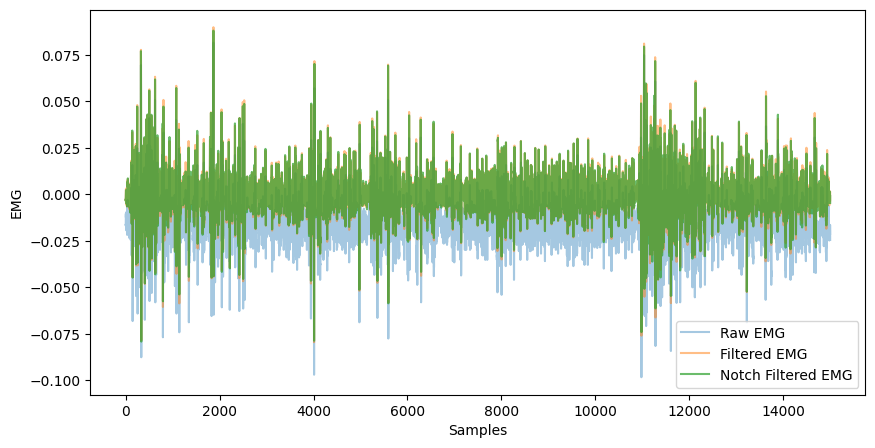

In [ ]:
from scipy import signal
import matplotlib.pyplot as plt
import numpy as np
from extract import butter_bandpass_filter
from scipy.ndimage import gaussian_filter1d
from extract import rms_smoothing

window_ms = 10
window_samples = int(1777 * window_ms / 1000)
window_samples3 = int(1777 * window_ms*3 / 1000)

filt2 = butter_bandpass_filter(EMG_1['EMG1'], 20, 450, 1777, order = 4)
gauss2 = gaussian_filter1d(np.abs(filt2), window_samples)
smooth2 = rms_smoothing(filt2, window_samples3)

raw2 = pd.to_numeric(EMG_1['EMG1'], errors='coerce')[185000:200000].to_numpy()
filtered2 = np.asarray(filt2)[185000:200000]
rms2 = np.asarray(smooth2)[185000:200000]
gauss_filt2 = np.asarray(gauss2)[185000:200000]

b, a = signal.iirnotch(60, 30, 1777)

# 4. Apply the filter using zero-phase filtering
filtered_signal = signal.filtfilt(b, a, filtered2)

plt.figure(figsize=(10,5))
plt.plot(raw2, alpha=0.4, label="Raw EMG")
plt.plot(filtered2, alpha=0.5, label="Filtered EMG")
plt.plot(filtered_signal, alpha=0.7, label="Notch Filtered EMG")
#plt.plot(rms2, linewidth=2, label="RMS (90 ms)")
#plt.plot(gauss_filt2, label = "Gaussian Filtered")
plt.xlabel("Samples")
plt.ylabel("EMG")
plt.legend()
plt.show()

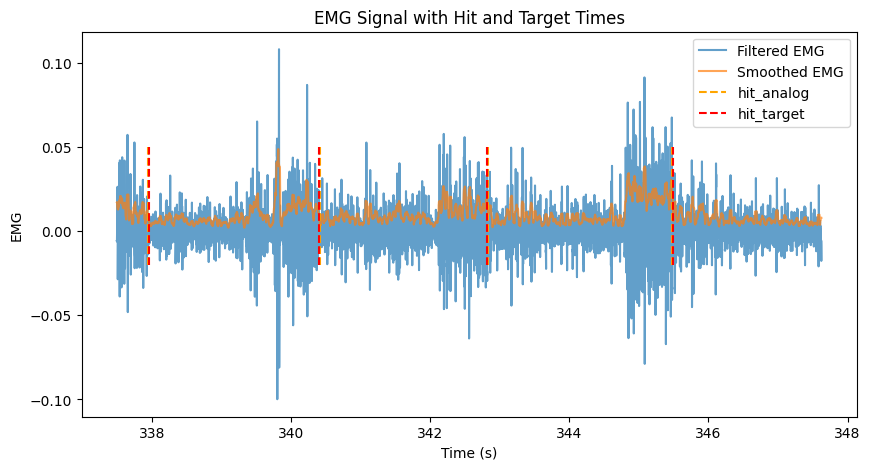

In [ ]:
filtered = np.asarray(filt2)
smooth = rms_smoothing(filt2, window_samples3)
plt.figure(figsize=(10,5))
plt.plot(EMG_1['Time'][600000:618000],filtered[600000:618000], alpha=0.7, label="Filtered EMG")
plt.plot(EMG_1['Time'][600000:618000],smooth[600000:618000], alpha=0.7, label="Smoothed EMG")

plt.vlines(x=hit_time_analog[115:119], ymax=0.05, ymin=-0.02, color = 'orange', linestyle="--", label="hit_analog")
plt.vlines(x=hit_time_target[115:119], ymax=0.05, ymin=-0.02, color = 'red', linestyle="--", label="hit_target")
plt.title("EMG Signal with Hit and Target Times")
plt.xlabel("Time (s)")
plt.ylabel("EMG")
plt.legend()  

In [ ]:
short_EMG = EMG_1[600000:602000].copy()
EMG_1_resamp = short_EMG.copy()
EMG_1_resamp['Time'] = pd.to_datetime(EMG_1_resamp['Time'], unit='s')
EMG_1_resamp = EMG_1_resamp.set_index('Time')
EMG_1_resamp = EMG_1_resamp.resample('1ms').mean().interpolate(method='linear')
EMG_1_resamp = EMG_1_resamp.reset_index()

EMG_1_dt = short_EMG.copy()
EMG_1_dt['Time'] =  pd.to_datetime(EMG_1_dt['Time'], unit='s')

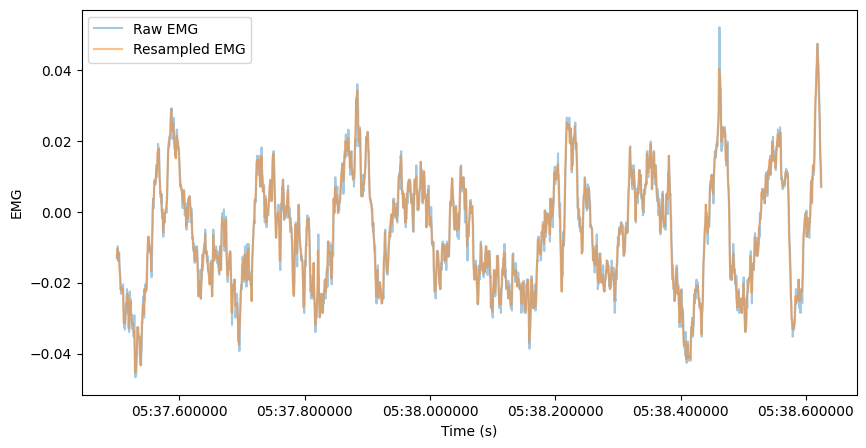

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(EMG_1_dt['Time'], EMG_1_dt['EMG1'], alpha=0.4, label="Raw EMG")
plt.plot(EMG_1_resamp['Time'], EMG_1_resamp['EMG1'], alpha=0.5, label="Resampled EMG")
plt.xlabel("Time (s)")
plt.ylabel("EMG")
plt.legend()

In [ ]:
# Once start and stop times are identified, we can use them to segment the EMG and IMU data into trials. The EMG signal will be normalized based on the maximum within task value.



In [ ]:
###IMU Preprocessing 

accel_1 = delsys_data[['ACC X Time Series (s)', 'ACC X (G)', 'ACC Y (G)', 'ACC Z (G)']].dropna()
accel_1.columns = ['Time', 'X', 'Y', 'Z']

plt.plot(accel_1['Time'], accel_1['X'], label='X-axis')



NameError: name 'delsys_data' is not defined